# ZEN Tutorial - Reverse Normalisation

## About

Often shared or publically downloadable bigWigs come pre-normalised. However, this can be problematic if comparing samples across experiments normalised in different ways or when applying a different method such as ZEN. This tutorial explains how the package [ZEN-norm](https://github.com/Genome-Function-Initiative-Oxford/Zone-Equalisation-Normalisation/tree/main) can test whether a bigWig has already been normalised and to reverse linear bigWig normalisation. For guidance on bigWig normalisation, see the [ZEN Tutorial](https://github.com/Genome-Function-Initiative-Oxford/Zone-Equalisation-Normalisation/tree/main/tutorials/zen_tutorial).

<a href="https://github.com/Genome-Function-Initiative-Oxford/Zone-Equalisation-Normalisation"><p><img src="https://raw.githubusercontent.com/Genome-Function-Initiative-Oxford/Zone-Equalisation-Normalisation/refs/heads/assets/Images/ZEN_Overview_Figure.png" style="max-width:1000px" width="100%"></p></a>

**Citation:** [T. Wilson, TA. Milne, SG. Riva and JR. Hughes, _Zone Equalisation Normalisation For Improved Alignment of Epigenetic Signal_, bioRxiv, 2025](https://www.biorxiv.org/content/10.64898/2025.12.10.693203v1)

## Table of Contents

1. [Imports and Set Up](#imports)
2. [Download Example Datasets](#data)
3. [Testing for Prior bigWig Normalisation](#test-norm)
4. [Reversing Linear bigWig Normalisation](#reverse-norm)

## 1) Imports and Set Up <a id="imports"></a>

Import the ZEN-norm modules, other packages, and global parameters used throughout the notebook. 
* If ZEN-norm is not installed, see the [GitHub repository](https://github.com/Genome-Function-Initiative-Oxford/Zone-Equalisation-Normalisation/tree/main).
* Set `cores` as the number of processors to enable parallelisation.

In [ ]:
import os
from ZEN_norm.reverse_norm import ReverseNorm

# Max number of processors to use (set for your system)
cores = 12

## 2) Download Example Datasets <a id="data"></a>

Run `downloadFTP` to download publically hosted datasets to test for prior bigWig normalisation:
* Unnormalised erythroid day 13 donor 2 ATAC-seq ([GSE311157](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE311157))
* Signal Per Million Reads (SPMR) normalised E14 mouse embryonic stem cell (mESC) H3K27ac ChIP-seq from ENCODE ([GSE31039](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE31039))

In [ ]:
# Download unnormalised erythroid donor 2 ATAC-seq bigWigs
ReverseNorm.downloadFTP(directory = "Example_Data/Erythroid_ATAC/BigWigs", 
                        ftp_paths = ["https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM9320nnn/GSM9320314/suppl/GSM9320314%5FDon002%5FATAC%5Fd13%5Frep1.bw"],
                        replace_existing = False)

# Download normalised E0 mESC H3K27ac ChIP-seq bigWigs
ReverseNorm.downloadFTP(directory = "Example_Data/mESC_H3K27ac/BigWigs", 
                        ftp_paths = ["https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM1000126&format=file&file=GSM1000126%5Fmm9%5FwgEncodeLicrHistoneEse14H3k27acME0129olaStdSig%2EbigWig"],
                        replace_existing = False)

## 3) Testing for Prior bigWig Normalisation <a id="test-norm"></a>

Module `ReverseNorm` has features to test whether bigWigs have already been normalised.

When initialising `ReverseNorm`, set the following parameters:
| Parameter | Description | Usage |
|------------|-------------|-------------|
| **`analysis_name`** | Custom output folder name. | Recommended. Defaults to saving results to a folder named `Analysis` created in the current working directory. |
| **`bigwig_paths`** | List or directory of `.bw` and/or `.bigWig` files. | Required unless `bam_paths` is given (see [Inputting BAMs](#inputs-bams)). |
| **`n_cores`** | Number of processors to use. | Defaults to one core. |

To quickly check each sample for prior normalisation, run `testNorm` with the following:

| Parameter | Description | Usage |
|------------|-------------|-------------|
| **`chromosomes`** | List of chromosomes to estimate fragment size from. Generally a small autosomal chromosome, e.g. chr21 for human or chr19 for mouse, is sufficient for accurate fragment size estimation. | By default, all chromosomes are used. But setting one chromosome is recommended for speed. |

In [ ]:
# Example for non-normalised erythroid ATAC-seq
ery_rev = ReverseNorm(analysis_name = "Erythroid_ATAC",
                      bigwig_paths = ["Example_Data/Erythroid_ATAC/BigWigs/GSM9320314_Don002_ATAC_d13_rep1.bw"],
                      n_cores = cores)
# Determine normalisation status per sample
ery_norm_status = ery_rev.testNorm(chromosomes = ["chr21"])

Opening 1 bigWig files
Setting chromosomes as autosomal and sex chromosomes
Estimating fragment sizes from 1 chromosome for 1 sample


No samples were pre-normalised


In [ ]:
# Example for SPMR normalised mESC H3K27ac ChIP-seq
mesc_rev = ReverseNorm(analysis_name = "mESC_H3K27ac",
                       bigwig_paths = "Example_Data/mESC_H3K27ac/BigWigs",
                       n_cores = cores)
# Determine normalisation status per sample
norm_status = mesc_rev.testNorm(chromosomes = ["chr19"])

Opening 1 bigWig files
Setting chromosomes as autosomal and sex chromosomes
Estimating fragment sizes from 1 chromosome for 1 sample
All samples were pre-normalised


## 4) Reversing Linear bigWig Normalisation <a id="reverse-norm"></a>

If bigWigs were pre-normalised, the transformation can be reversed if it was linear. I.e. if a genome-wide signal $y$ is scaled by a constant factor $s$ to create $y^{\eta}$:

$$
y^{\eta} = y \cdot s
$$

The original signal $y$ can be retrieved by diving by $s$. Although $s$ is generally unknown for pre-normalised bigWigs, `ReverseNorm` can approximate it assuming two common properties of genomic data hold:
* After a linear normalisation, a signal value representing one read has the value $1 \cdot s = s$.
* Abundant background noise makes it almost certain that at least one genomic position has signal from only one read.

Examples of linear normalisation methods include RPKM, CPM, BPM, RPGC, LIB, TMM, RLE and RRPM.

### 4.1) mESC H3K27ac ChIP-seq Example

ENCODE bigWigs such as the mESC H3K27ac ChIP-seq are normalised by MACS SPMR:

$$
\mathrm{SPMR} = \frac{\text{fragment pileup signal}}{\text{total reads} / 10^{6}}
$$

From the formula, we see that SPMR is a linear library size normalisation. This is equivalent to:

$$
y^{\eta} = y \cdot \frac{10^{6}}{\text{total reads}},
$$

Therefore scaling factor $s$ is:

$$
s = \frac{10^{6}}{\text{total reads}}
$$

Using method `runReversal` to approximate a scaling factor $\hat{s}$ such that $\hat{s} \approx s$, the unnormalised signal can therefore be recovered as:

$$
y \approx \frac{y^{\eta}}{\hat{s}}.
$$

All `runReversal` parameters are optional:

| Parameter | Description | Usage |
|------------|-------------|-------------|
| **`chromosomes`** | List of chromosomes to estimate fragment size from. Generally a small autosomal chromosome, e.g. chr21 for human or chr19 for mouse, is sufficient for accurate fragment size estimation. | By default, all chromosomes are used. But setting one chromosome is recommended for speed. |
| **`replace_existing`** | If set as `True`, any existing output files generated by this method will be recreated. This is useful if a previous run was interrupted and produced incomplete or corrupt files. If `False` (default), only missing files will be generated without overwriting existing ones. | Use only to recreate files after a previous run. |

In [5]:
# Create reverse normalised bigWigs
mesc_rev.runReversal(chromosomes = ["chr19"], replace_existing = False)

Reverse normalised bigWigs already created for all samples


Genomic signal before and after reverse normalisation can be viewed with `plotTracks`. 

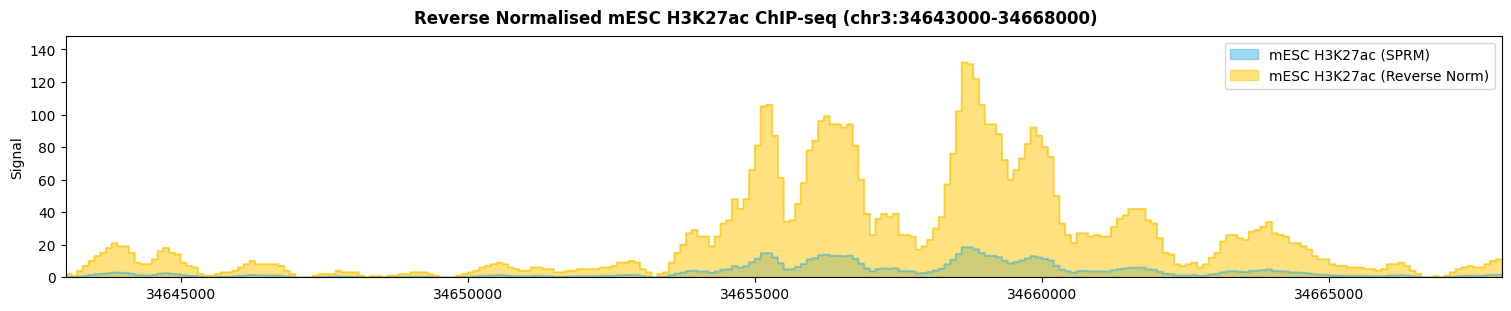

In [30]:
# Coordinates of mouse SOX2 locus
mm10_sox2_coords = {"chrom": "chr3",
                    "start": 34643000,
                    "end": 34668000}

# Plot SPRM and reverse normalised signal
title = f"Reverse Normalised mESC H3K27ac ChIP-seq "
title += f"({mm10_sox2_coords['chrom']}:{mm10_sox2_coords['start']}-{mm10_sox2_coords['end']})"

mesc_rev.plotTracks(chromosome = mm10_sox2_coords["chrom"],
                    start_coord = mm10_sox2_coords["start"],
                    end_coord = mm10_sox2_coords["end"],
                    plot_bigwigs = ["example_data/mesc_h3k27ac/GSM1000126_mm9_wgEncodeLicrHistoneEse14H3k27acME0129olaStdSig.bigWig",
                                    "mESC_H3K27ac/Results/BigWigs/Reverse_Normalised/GSM1000126_mm9_wgEncodeLicrHistoneEse14H3k27acME0129olaStdSig_reverse_norm.bw"],
                    plot_labels = ["mESC H3K27ac (SPRM)", "mESC H3K27ac (Reverse Norm)"],
                    custom_colours = ["#41B6E6", "#FFC400"],
                    overlay_plots = True,
                    main_title = title)